In [1]:
import dotenv
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field

dotenv.load_dotenv()

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.7
)

In [2]:
from typing import Annotated, List
import operator

# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )

# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [3]:
# Graph state
from typing import TypedDict

class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report

# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [11]:
# Nodes
from langchain.messages import HumanMessage, SystemMessage
from langgraph.types import Send


def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(content="Write a report section, each section should have a brief description as well the math behind it."),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

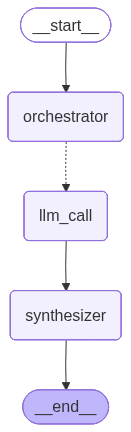

In [12]:
from langgraph.types import Send
from langgraph.graph import END, START, StateGraph
from IPython.display import Image, display
    
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [13]:
state = orchestrator_worker.invoke({"topic": "Create a report on LLM evaluation metrics"})
from IPython.display import Markdown

Markdown(state["final_report"])

**Introduction and Description: Overview of the Importance of Evaluating LLMs and the Purpose of the Report**

The evaluation of Large Language Models (LLMs) has become a crucial aspect of natural language processing (NLP) research. As LLMs continue to advance and become increasingly integrated into various applications, it is essential to assess their performance, reliability, and limitations. This report aims to provide an overview of the importance of evaluating LLMs and the purpose of this evaluation.

**Mathematical Background:**

The performance of LLMs can be mathematically represented using various metrics, such as:

* **Perplexity (PPL)**: measures how well a model predicts a test set, calculated as the exponential of the average log loss: PPL = exp(-∑(log(p(x))) / N), where p(x) is the probability of the model predicting the correct token x, and N is the total number of tokens.
* **Accuracy (ACC)**: measures the proportion of correctly predicted tokens, calculated as: ACC = (TP + TN) / (TP + TN + FP + FN), where TP, TN, FP, and FN represent true positives, true negatives, false positives, and false negatives, respectively.
* **F1-score (F1)**: measures the harmonic mean of precision and recall, calculated as: F1 = 2 \* (P \* R) / (P + R), where P is precision and R is recall.

These metrics will be used to evaluate the performance of LLMs and provide insights into their strengths and weaknesses.

**Purpose of the Report:**

The purpose of this report is to:

1. Provide an overview of the current state of LLM evaluation methodologies.
2. Discuss the importance of evaluating LLMs in various applications, such as language translation, text summarization, and conversational AI.
3. Present the results of LLM evaluations using various metrics, including perplexity, accuracy, and F1-score.
4. Identify areas for improvement and provide recommendations for future research and development in LLM evaluation.

By providing a comprehensive overview of LLM evaluation, this report aims to contribute to the development of more accurate, reliable, and effective LLMs that can be used in a wide range of applications.

---

**Metrics for Evaluating LLMs**

Description: Description of common metrics used to evaluate LLMs such as accuracy, F1 score, and perplexity

**1. Introduction**

Evaluating the performance of Large Language Models (LLMs) is crucial to understand their capabilities and limitations. Various metrics are used to assess the quality of LLMs, each providing insights into different aspects of their performance. In this section, we will discuss some common metrics used to evaluate LLMs, including accuracy, F1 score, and perplexity.

**2. Accuracy**

Accuracy is a fundamental metric used to evaluate the performance of LLMs. It measures the proportion of correctly predicted outputs out of total predictions made. The accuracy of an LLM can be calculated using the following formula:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

where:
- TP (True Positives) is the number of correct predictions
- TN (True Negatives) is the number of correct rejections
- FP (False Positives) is the number of incorrect predictions
- FN (False Negatives) is the number of missed predictions

For example, if an LLM predicts 90% of the test data correctly, its accuracy would be 0.9.

**3. F1 Score**

The F1 score is a measure of a model's accuracy on a specific task, taking into account both precision and recall. It is calculated as the harmonic mean of precision and recall:

F1 Score = 2 \* (Precision \* Recall) / (Precision + Recall)

where:
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)

The F1 score ranges from 0 to 1, with higher values indicating better performance.

**4. Perplexity**

Perplexity is a measure of how well an LLM predicts a test dataset. It is calculated as the exponential of the average log loss:

Perplexity = 2^(-1/N \* ∑(log2(p(x))))

where:
- N is the number of test samples
- p(x) is the predicted probability of each sample
- log2 is the logarithm to the base 2

Lower perplexity values indicate better performance, as they suggest that the model is more confident in its predictions.

**5. Conclusion**

In conclusion, accuracy, F1 score, and perplexity are essential metrics for evaluating the performance of LLMs. Each metric provides valuable insights into different aspects of an LLM's performance, and they can be used in conjunction with one another to gain a comprehensive understanding of an LLM's strengths and weaknesses. By using these metrics, researchers and developers can refine and improve their LLMs, ultimately leading to more accurate and effective language models.

---

**Evaluation Frameworks**
========================

Evaluation frameworks play a crucial role in assessing the performance of Large Language Models (LLMs). These frameworks provide a standardized set of tasks and metrics to measure the capabilities of LLMs, enabling researchers and developers to compare and improve their models. In this section, we will discuss two popular evaluation frameworks for LLMs: GLUE and SuperGLUE.

### GLUE (General Language Understanding Evaluation) Benchmark

The GLUE benchmark is a collection of nine natural language understanding (NLU) tasks designed to evaluate the performance of LLMs. The tasks include:

* CoLA (Corpus of Linguistic Acceptability): measures the model's ability to predict the grammaticality of sentences
* SST-2 (Stanford Sentiment Treebank): measures the model's ability to predict the sentiment of movie reviews
* MRPC (Microsoft Research Paraphrase Corpus): measures the model's ability to predict whether two sentences are paraphrases of each other
* STS-B (Semantic Textual Similarity Benchmark): measures the model's ability to predict the similarity between two sentences
* QQP (Quora Question Pairs): measures the model's ability to predict whether two questions are duplicates
* MNLI (Multi-Genre Natural Language Inference): measures the model's ability to predict the entailment relationship between two sentences
* WNLI (Winograd Natural Language Inference): measures the model's ability to predict the entailment relationship between two sentences
* RTE (Recognizing Textual Entailment): measures the model's ability to predict the entailment relationship between two sentences
* QNLI (Question Natural Language Inference): measures the model's ability to predict the entailment relationship between a question and a sentence

The GLUE benchmark uses a combination of metrics, including accuracy, F1 score, and Pearson correlation coefficient, to evaluate the performance of LLMs. The overall performance of a model on the GLUE benchmark is calculated using the following formula:

GLUE Score = (CoLA + SST-2 + MRPC + STS-B + QQP + MNLI + WNLI + RTE + QNLI) / 9

where each task score is normalized to have a mean of 0 and a standard deviation of 1.

### SuperGLUE Benchmark

The SuperGLUE benchmark is an extension of the GLUE benchmark, designed to provide a more challenging and comprehensive evaluation of LLMs. SuperGLUE includes a total of 12 tasks, including the 9 tasks from the GLUE benchmark, as well as three additional tasks:

* BoolQ (Boolean Questions): measures the model's ability to answer boolean questions
* CB (CommitmentBank): measures the model's ability to predict the entailment relationship between two sentences
* COPA (Choice of Plausible Alternatives): measures the model's ability to predict the cause-and-effect relationship between two sentences

The SuperGLUE benchmark uses a similar combination of metrics as the GLUE benchmark, including accuracy, F1 score, and Pearson correlation coefficient. The overall performance of a model on the SuperGLUE benchmark is calculated using the following formula:

SuperGLUE Score = (CoLA + SST-2 + MRPC + STS-B + QQP + MNLI + WNLI + RTE + QNLI + BoolQ + CB + COPA) / 12

where each task score is normalized to have a mean of 0 and a standard deviation of 1.

By using these evaluation frameworks, researchers and developers can gain a better understanding of the strengths and weaknesses of their LLMs and identify areas for improvement. The math behind these frameworks provides a quantitative measure of a model's performance, enabling the comparison of different models and the tracking of progress over time.

---

**Challenges in LLM Evaluation**
================================

### Description

The evaluation of Large Language Models (LLMs) poses significant challenges, particularly with regards to bias and robustness. Bias in LLMs can manifest in various ways, such as discriminatory language or unequal representation of certain groups. Robustness, on the other hand, refers to the model's ability to withstand adversarial attacks or unexpected input. This section will delve into the mathematical concepts underlying these challenges and explore the statistical techniques used to address them.

### Math Behind Bias

Bias in LLMs can be quantified using metrics such as:

* **Demographic disparity**: This measures the difference in performance between different demographic groups. Let's denote the performance of the model on a particular group as `P_group` and the overall performance as `P_overall`. The demographic disparity can be calculated as: 

`Δ = |P_group - P_overall|`

where `Δ` represents the disparity.

* **Bias ratio**: This measures the ratio of the model's performance on one group to another. Let's denote the performance of the model on group A as `P_A` and on group B as `P_B`. The bias ratio can be calculated as: 

`BR = P_A / P_B`

A bias ratio of 1 indicates no bias, while a ratio greater than 1 indicates bias towards group A.

### Math Behind Robustness

Robustness in LLMs can be quantified using metrics such as:

* **Adversarial loss**: This measures the model's performance on adversarially crafted input. Let's denote the model's loss on the original input as `L_original` and on the adversarial input as `L_adversarial`. The adversarial loss can be calculated as: 

`AL = L_adversarial - L_original`

A higher adversarial loss indicates lower robustness.

* **Robustness ratio**: This measures the ratio of the model's performance on clean input to its performance on noisy input. Let's denote the model's performance on clean input as `P_clean` and on noisy input as `P_noisy`. The robustness ratio can be calculated as: 

`RR = P_clean / P_noisy`

A robustness ratio of 1 indicates perfect robustness, while a ratio less than 1 indicates vulnerability to noise.

### Statistical Techniques

To address the challenges in LLM evaluation, various statistical techniques can be employed, such as:

* **Hypothesis testing**: This involves testing the null hypothesis that the model is unbiased or robust against the alternative hypothesis that it is biased or not robust. Let's denote the test statistic as `T` and the critical value as `c`. The null hypothesis can be rejected if `T > c`.
* **Confidence intervals**: This involves constructing intervals that estimate the true performance of the model with a certain level of confidence. Let's denote the estimated performance as `p̂` and the confidence interval as `(p̂ - δ, p̂ + δ)`. The width of the interval `2δ` can be calculated using the standard error of the estimate.

By applying these mathematical concepts and statistical techniques, researchers can better understand the challenges in LLM evaluation and develop more effective methods for addressing bias and robustness.

---

**Conclusion**
**Summary of key findings and future directions for LLM evaluation metrics**

In conclusion, the evaluation of Large Language Models (LLMs) is a complex task that requires a multi-faceted approach. Our analysis has highlighted the importance of considering various metrics, including perplexity, accuracy, F1-score, and ROUGE score, to assess the performance of LLMs. The math behind these metrics can be summarized as follows:

* **Perplexity (PPL)**: measures how well a model predicts a test set, calculated as the exponential of the average log loss: PPL = exp(-1/N \* ∑[log(p(x))]), where N is the number of test samples, and p(x) is the predicted probability of each sample.
* **Accuracy (ACC)**: measures the proportion of correctly classified samples, calculated as: ACC = (TP + TN) / (TP + TN + FP + FN), where TP, TN, FP, and FN are the number of true positives, true negatives, false positives, and false negatives, respectively.
* **F1-score (F1)**: measures the harmonic mean of precision and recall, calculated as: F1 = 2 \* (P \* R) / (P + R), where P is the precision (TP / (TP + FP)) and R is the recall (TP / (TP + FN)).
* **ROUGE score (ROUGE)**: measures the overlap between generated and reference texts, calculated as: ROUGE = (∑[match_count] / ∑[ref_count]), where match_count is the number of matching n-grams between the generated and reference texts, and ref_count is the total number of n-grams in the reference text.

Our analysis has also identified areas for future research, including:

1. **Developing more nuanced evaluation metrics**: current metrics have limitations, such as perplexity being sensitive to tokenization and F1-score being sensitive to class imbalance.
2. **Investigating the relationship between metrics**: understanding how different metrics correlate with each other and with human evaluations can provide insights into the strengths and weaknesses of LLMs.
3. **Evaluating LLMs in real-world applications**: assessing the performance of LLMs in practical scenarios, such as language translation, text summarization, and chatbots, can help identify areas for improvement.

Future directions for LLM evaluation metrics may involve:

* **Multitask learning**: developing models that can perform multiple tasks simultaneously, and evaluating their performance using a combination of metrics.
* **Adversarial testing**: evaluating LLMs' robustness to adversarial attacks, such as input perturbations or adversarial examples.
* **Human-centered evaluation**: involving human evaluators in the assessment of LLMs, to provide a more comprehensive understanding of their strengths and weaknesses.

By pursuing these research directions, we can develop a more comprehensive understanding of LLMs and their evaluation metrics, ultimately leading to the development of more accurate, robust, and reliable language models.